# Wine Quality Data Cleaning & Feature Engineering


## 1) Imports And Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")

from utils import (
    load_data,
    binarize_quality,
    drop_quality,
    create_features,
    preprocess_data
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

%matplotlib inline


In [2]:
wine = load_data("data/winequality-red.csv")

print("Dataset shape:", wine.shape)
display(wine.head())



Dataset shape: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2) Check data quality

In [3]:
print("\nMissing values per column:")
print(wine.isnull().sum())

print("\nTotal missing:", wine.isnull().sum().sum())
print("Duplicate rows:", wine.duplicated().sum())




Missing values per column:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing: 0
Duplicate rows: 240


## 3) Convert quality to binary

In [4]:
wine_bin = binarize_quality(wine, threshold=7)

print("\nClass counts:")
print(wine_bin["good_quality"].value_counts())

ratio = wine_bin["good_quality"].mean()
print(f"Proportion of good wines: {ratio:.3f}")



Class counts:
good_quality
0    1382
1     217
Name: count, dtype: int64
Proportion of good wines: 0.136


## 4) Distribution Comparison Before/After

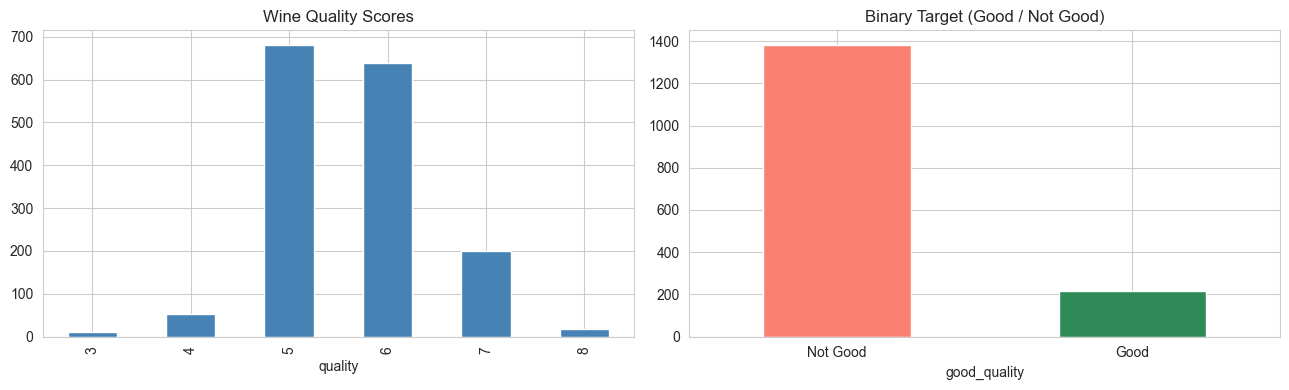

In [5]:
fig, ax = plt.subplots(1,2, figsize=(13,4))

wine["quality"].value_counts().sort_index().plot(
    kind="bar",
    color="steelblue",
    ax=ax[0]
)
ax[0].set_title("Wine Quality Scores")

wine_bin["good_quality"].value_counts().plot(
    kind="bar",
    color=["salmon","seagreen"],
    ax=ax[1]
)

ax[1].set_title("Binary Target (Good / Not Good)")
ax[1].set_xticklabels(["Not Good","Good"], rotation=0)

plt.tight_layout()
plt.show()


## 5) Feature engineering

In [6]:
wine_no_quality = drop_quality(wine_bin)

wine_features = create_features(wine_no_quality)

added_features = [
    c for c in wine_features.columns
    if c not in wine_no_quality.columns
]

print("\nEngineered features:", added_features)

display(wine_features.head())




Engineered features: ['total_acidity', 'acidity_ratio', 'free_to_total_sulfur', 'alcohol_level']


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,good_quality,total_acidity,acidity_ratio,free_to_total_sulfur,alcohol_level
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,8.68,8.863636,0.373134,medium
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,8.56,10.263158,0.277778,medium
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,11.48,40.000000,0.283333,medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,low


**Compare feature ratios by class**

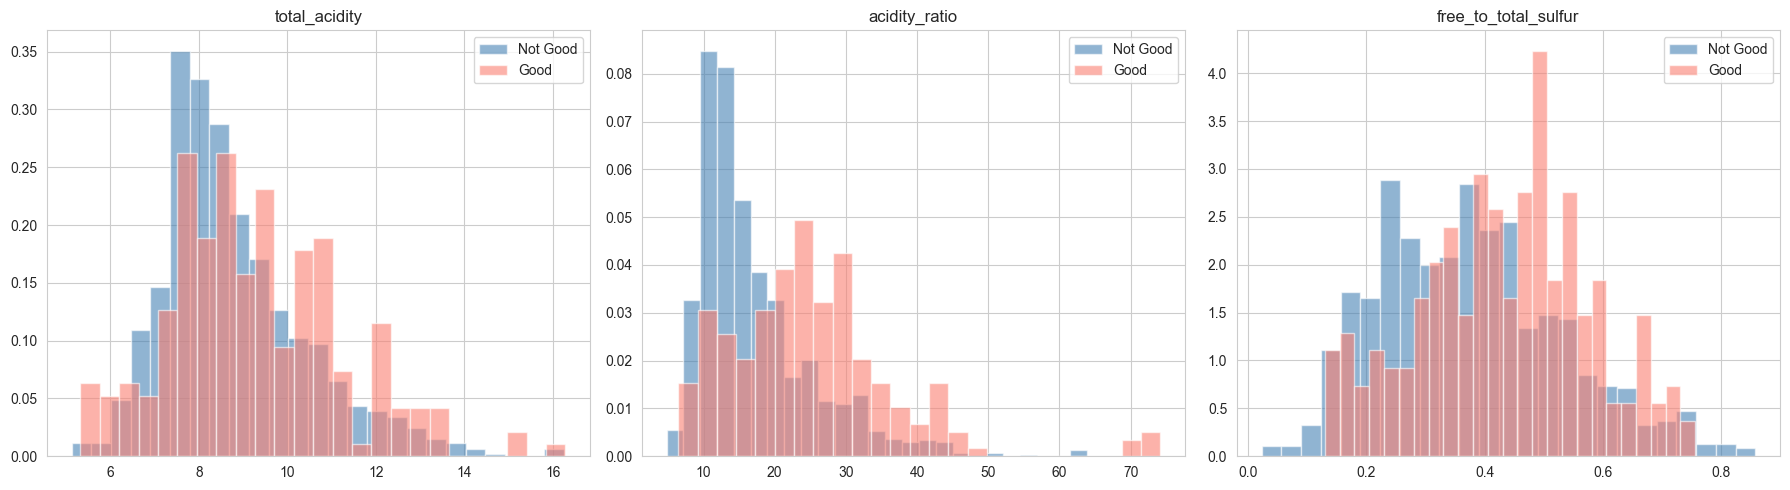

In [7]:
ratio_cols = ["total_acidity", "acidity_ratio", "free_to_total_sulfur"]

fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(ratio_cols):

    for label, color, name in [
        (0, "steelblue", "Not Good"),
        (1, "salmon", "Good")
    ]:

        subset = wine_features[wine_features["good_quality"] == label][col]

        axes[i].hist(
            subset,
            bins=25,
            alpha=0.6,
            color=color,
            density=True,
            label=name
        )

    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()


**Alcohol level distribution**

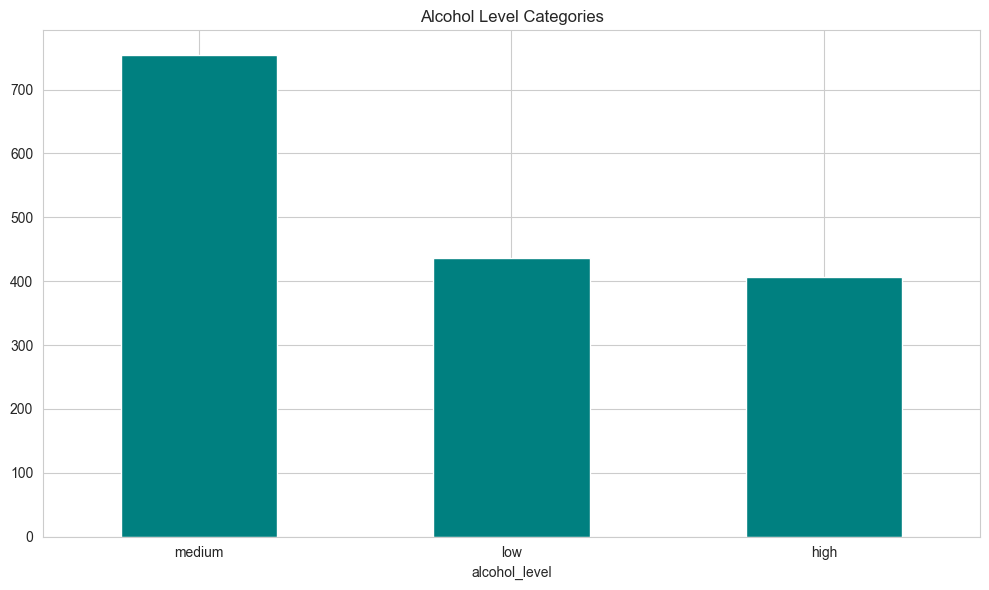


Good wine rate per alcohol level:
alcohol_level
low       0.009
medium    0.095
high      0.346
Name: good_quality, dtype: float64


In [8]:
wine_features["alcohol_level"].value_counts().plot(
    kind="bar",
    color="teal"
)

plt.title("Alcohol Level Categories")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nGood wine rate per alcohol level:")
print(
    wine_features
    .groupby("alcohol_level", observed=True)["good_quality"]
    .mean()
    .round(3)
)

## 6) Final preprocessing pipeline

In [9]:
wine_clean = preprocess_data(wine, threshold=7)

print("\nProcessed dataset shape:", wine_clean.shape)
print("Remaining missing values:", wine_clean.isnull().sum().sum())

display(wine_clean.head())



Processed dataset shape: (1599, 17)
Remaining missing values: 0


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,good_quality,total_acidity,acidity_ratio,free_to_total_sulfur,alcohol_level_medium,alcohol_level_high
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,False,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,8.68,8.863636,0.373134,True,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,8.56,10.263158,0.277778,True,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,11.48,40.000000,0.283333,True,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,False,False


## 7) Sanity Checks

In [10]:
assert wine_clean["good_quality"].isin([0,1]).all()
assert wine_clean.isnull().sum().sum() == 0
assert "quality" not in wine_clean.columns

print("All validation checks passed.")



All validation checks passed.


In [11]:
output_path = "data/winequality-red_cleaned.csv"
wine_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved")

Cleaned dataset saved
